### This is the notebook for analyzing UCEC data

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
from scipy.sparse import csr_matrix

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

import gseapy as gp
from gseapy import barplot, dotplot
from gseapy import Msigdb

import mygene
mg = mygene.MyGeneInfo()

import sys
sys.path.append("..")

from scripts.utility_functions import t_test, clean_data, read_data


omic_type = "proteomics"


##### Step 1: combine all cancer type into one adata object

In [ ]:
### Test
### Skip
cancer_type = "CCRCC"
object_file = f"../../MultiOmics_cancer_landscape_data/{cancer_type}/Object/{cancer_type}_{omic_type}.h5ad"
adata_CCRCC = ad.read_h5ad(object_file)

cancer_type = "COAD"
object_file = f"../../MultiOmics_cancer_landscape_data/{cancer_type}/Object/{cancer_type}_{omic_type}.h5ad"
adata_COAD = ad.read_h5ad(object_file)
adata_COAD.obs["Cancer_type"] = cancer_type

cancer_type = "HNSCC"
object_file = f"../../MultiOmics_cancer_landscape_data/{cancer_type}/Object/{cancer_type}_{omic_type}.h5ad"
adata_HNSCC = ad.read_h5ad(object_file)
adata_HNSCC.obs["Cancer_type"] = cancer_type

common_genes = list(set.intersection(set(adata_CCRCC.var_names), set(adata_COAD.var_names), set(adata_HNSCC.var_names)))

adata_CCRCC = adata_CCRCC[:, common_genes].copy()
adata_COAD = adata_COAD[:, common_genes].copy()
adata_HNSCC = adata_HNSCC[:, common_genes].copy()

merged_adata = ad.concat([adata_CCRCC, adata_COAD, adata_HNSCC] ,join="inner", merge="same")

In [2]:
# ---------------------------------------------------------
# User settings
# ---------------------------------------------------------
cancer_types = ["CCRCC", "COAD", "HNSCC", "LSCC", "LUAD", "OV", "PDAC", "UCEC"]  # fill in your list

base_path = "../../MultiOmics_cancer_landscape_data"
adata_dict = {}

# ---------------------------------------------------------
# 1) Load all adatas and store in dictionary
# ---------------------------------------------------------
for ct in cancer_types:
    object_file = f"{base_path}/{ct}/Object/{ct}_{omic_type}.h5ad"
    
    print(f"Loading: {object_file}")
    adata = ad.read_h5ad(object_file)

    # Add cancer type column
    adata.obs["CancerType"] = ct

    # Store
    adata_dict[ct] = adata

print("\nLoaded datasets:", list(adata_dict.keys()))

# ---------------------------------------------------------
# 2) Find common genes
# ---------------------------------------------------------
gene_sets = [set(a.var_names) for a in adata_dict.values()]
common_genes = list(set.intersection(*gene_sets))

print(f"Common genes found: {len(common_genes)}")

# ---------------------------------------------------------
# 3) Subset each AnnData to the common gene set
# ---------------------------------------------------------
for ct in adata_dict:
    adata_dict[ct] = adata_dict[ct][:, common_genes].copy()

# ---------------------------------------------------------
# 4) Concatenate into one AnnData
# ---------------------------------------------------------
merged_adata = ad.concat(
    adata_dict.values(),
    join="inner",
    merge="same"   
)

print(f"Merged shape: {merged_adata.shape}")  # (cells, genes)

# ---------------------------------------------------------
# 5) Save result
# ---------------------------------------------------------
#merged_adata.write("merged_adata.h5ad")
#print("\n✅ merged_adata.h5ad saved.")







Loading: ../../MultiOmics_cancer_landscape_data/CCRCC/Object/CCRCC_proteomics.h5ad
Loading: ../../MultiOmics_cancer_landscape_data/COAD/Object/COAD_proteomics.h5ad
Loading: ../../MultiOmics_cancer_landscape_data/HNSCC/Object/HNSCC_proteomics.h5ad
Loading: ../../MultiOmics_cancer_landscape_data/LSCC/Object/LSCC_proteomics.h5ad
Loading: ../../MultiOmics_cancer_landscape_data/LUAD/Object/LUAD_proteomics.h5ad
Loading: ../../MultiOmics_cancer_landscape_data/OV/Object/OV_proteomics.h5ad
Loading: ../../MultiOmics_cancer_landscape_data/PDAC/Object/PDAC_proteomics.h5ad
Loading: ../../MultiOmics_cancer_landscape_data/UCEC/Object/UCEC_proteomics.h5ad

Loaded datasets: ['CCRCC', 'COAD', 'HNSCC', 'LSCC', 'LUAD', 'OV', 'PDAC', 'UCEC']
Common genes found: 5149
Merged shape: (1332, 5149)


In [8]:
print(merged_adata)

AnnData object with n_obs × n_vars = 1332 × 5149
    obs: 'SampleType', 'Sample', 'CancerType'
    var: 'ensembl_ids_clean', 'Gene'


In [7]:
merged_adata.obs

,SampleType,Sample,CancerType
C3L-01287_N,N,C3L-01287,CCRCC
C3L-00561_N,N,C3L-00561,CCRCC
C3N-01524_N,N,C3N-01524,CCRCC
C3L-01603_N,N,C3L-01603,CCRCC
C3N-00834_N,N,C3N-00834,CCRCC
...,...,...,...
C3N-01802_T,T,C3N-01802,UCEC
C3N-00151_T,T,C3N-00151,UCEC
C3L-00136_T,T,C3L-00136,UCEC
C3L-00008_T,T,C3L-00008,UCEC


In [9]:
merged_adata.var

,ensembl_ids_clean,Gene
idx,,
ENSG00000188677.14,ENSG00000188677,PARVB
ENSG00000168066.20,ENSG00000168066,SF1
ENSG00000085872.15,ENSG00000085872,CHERP
ENSG00000047230.15,ENSG00000047230,CTPS2
ENSG00000101972.19,ENSG00000101972,STAG2
...,...,...
ENSG00000134463.15,ENSG00000134463,ECHDC3
ENSG00000106245.11,ENSG00000106245,BUD31
ENSG00000111011.18,ENSG00000111011,RSRC2


# Add the protein atlas gene description

In [ ]:
#object_file = f"../../MultiOmics_cancer_landscape_data/{cancer_type}/Object/{cancer_type}_{omic_type}.h5ad"

#adata.write(object_file, compression="gzip")

##### Step 2: ML

In [10]:
### Main ML workflow 

# Load data
#object_file = f"../../MultiOmics_cancer_landscape_data/{cancer_type}/Object/{cancer_type}_{omic_type}.h5ad"
#adata = ad.read_h5ad(object_file)
adata = merged_adata.copy()

X = adata.X
y_ori = adata.obs["SampleType"].values
#samples = adata.obs["Sample"].values  # sample names or IDs
samples_type = adata.obs["SampleType"].values
samples = adata.obs.index

# Encode labels
# LabelEncoder assigns integers alphabetically by default, so if your labels are "N" and "T" you’ll usually get "Normal" = 0, "Tumor" = 1
encoder = LabelEncoder()
y = encoder.fit_transform(y_ori)

# Ensure "Normal" = 0, "Tumor" = 1
if encoder.transform(["T"])[0] == 0:
    y = 1 - y  # flip labels

# Split train/test and also get the indices of the test set
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, range(len(y)), test_size=0.3, random_state=42, stratify=y, shuffle=True
)

adata_train = adata[samples[idx_train], ]
adata_test = adata[samples[idx_test], ]

# Train Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

adata_train = t_test(adata_obj = adata_train, sample_type_col= "SampleType", left_type = "T", right_type="N")

adata_train.var["feature_importance"] = rf.feature_importances_


In [11]:
rf

RandomForestClassifier(n_estimators=500, random_state=42)

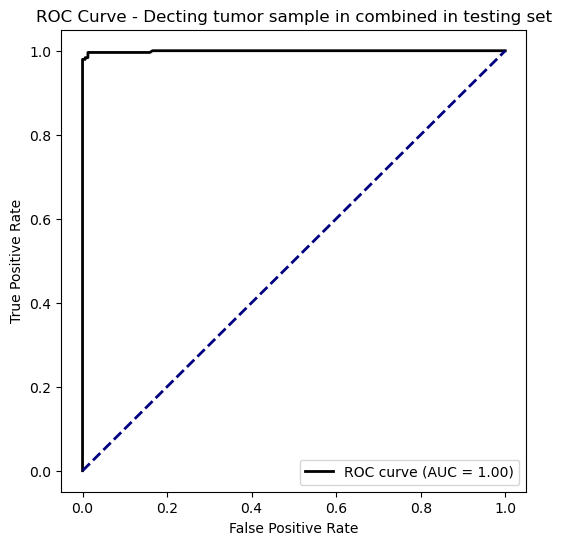

In [13]:
cancer_type = "combined"

### Prediction
y_proba = rf.predict_proba(X_test)[:, 1]  # Probability of class 1 (Tumor)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute AUC
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color = "black", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color = "navy", lw=2, linestyle= "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - Decting tumor sample in {cancer_type} in testing set")
plt.legend(loc="lower right")

# Save to PDF
pdf_file = f"../results/figures/{cancer_type}_{omic_type}_ROC_in_testing_set.pdf"
plt.savefig(pdf_file, format="pdf", bbox_inches="tight")

plt.show()


     idx_test       Sample Sample_Type  y_test  y_pred
0         413  C3L-00995_N           N       0   0.106
1         688  C3N-02675_T           T       1   0.940
2        1107  C3L-03639_N           N       0   0.128
3         551  C3L-01663_N           N       0   0.098
4         203    01CO014_N           N       0   0.026
..        ...          ...         ...     ...     ...
395       322    11CO054_T           T       1   0.974
396         8  C3L-00607_N           N       0   0.020
397       779  C3N-01016_N           N       0   0.050
398       890  C3N-02424_T           T       1   0.980
399       705  C3L-02660_T           T       1   0.774

[400 rows x 5 columns]


/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_73141/88673498.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=performance, x="Sample_Type", y="y_pred", palette=custom_palette)


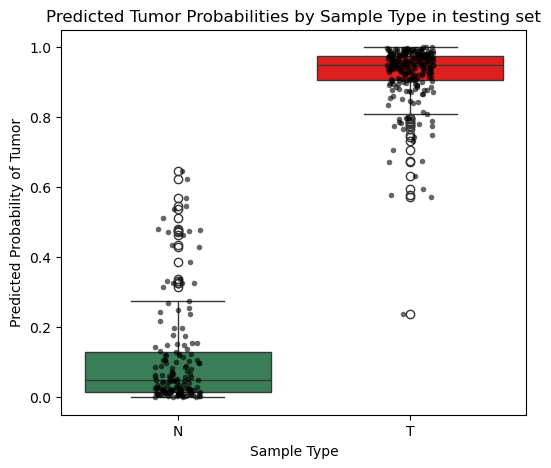

In [14]:

### Create performance DataFrame with Sample info and visualize the proba in testing set
performance = pd.DataFrame({
    "idx_test": idx_test,
    "Sample": samples[idx_test],   # sample names
    "Sample_Type": samples_type[idx_test],
    "y_test": y_test,
    "y_pred": y_proba
})

print(performance)

performance_sort = performance.sort_values("y_pred").reset_index(drop=True)

#pd.set_option("display.max_rows", None)
#print(performance_sort)

### Boxplot on the prediction score in testing set
custom_palette = {"N": "seagreen", "T": "red"}

plt.figure(figsize=(6,5))
sns.boxplot(data=performance, x="Sample_Type", y="y_pred", palette=custom_palette)
sns.stripplot(data=performance, x="Sample_Type", y="y_pred", color="black", size=4, jitter=True, alpha=0.6)
plt.ylabel("Predicted Probability of Tumor")
plt.xlabel("Sample Type")
plt.title("Predicted Tumor Probabilities by Sample Type in testing set")

# Save to PDF
pdf_file = f"../results/figures/{cancer_type}_{omic_type}_Proba_in_testing_set.pdf"
plt.savefig(pdf_file, format="pdf", bbox_inches="tight")

plt.show()

In [15]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
feature_importance_sort.head(5)

,ensembl_ids_clean,Gene,left_mean,right_mean,diff_mean,t_vals,p_vals,feature_importance
idx,,,,,,,,
ENSG00000106809.11,ENSG00000106809,OGN,28.33875443548739,30.092247566678015,-1.753493,-21.461408,1.092704e-75,0.013306
ENSG00000138442.10,ENSG00000138442,WDR12,24.641678112300635,23.89273460735333,0.748944,22.790066,4.942427e-88,0.008913
ENSG00000141526.16,ENSG00000141526,SLC16A3,24.017533901621242,23.069824225183414,0.947710,23.483123,3.026153e-95,0.008659
ENSG00000124383.9,ENSG00000124383,MPHOSPH10,24.002584195890726,23.381802757583113,0.620781,24.796551,7.986772e-103,0.008292
ENSG00000004776.13,ENSG00000004776,HSPB6,26.491158129642958,28.331105119235637,-1.839947,-21.594590,7.607408e-77,0.008195


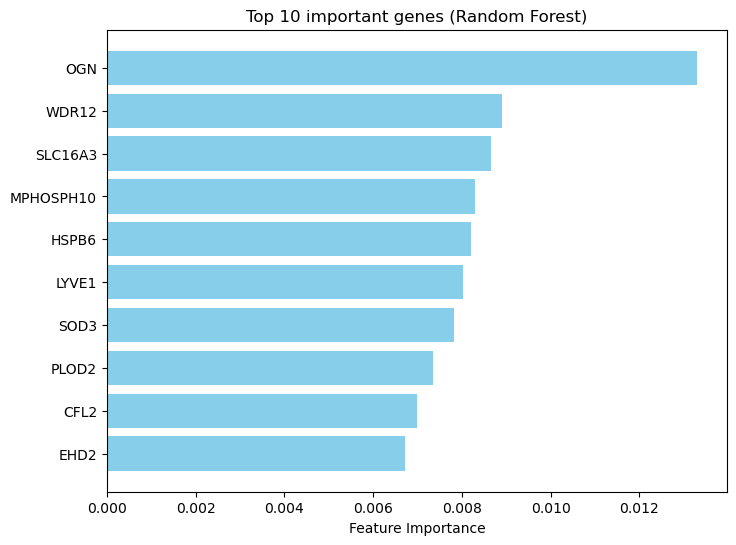

In [16]:
top_n = 10
plt.figure(figsize=(8,6))
plt.barh(
    feature_importance_sort['Gene'][:top_n][::-1],
    feature_importance_sort['feature_importance'][:top_n][::-1],
    color='skyblue'
)
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} important genes (Random Forest)")
plt.show()


#### Step 3: Explore the features with biological input

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_73141/1400845078.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


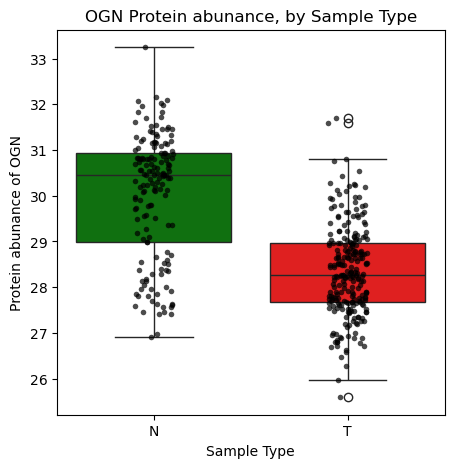

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_73141/1400845078.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


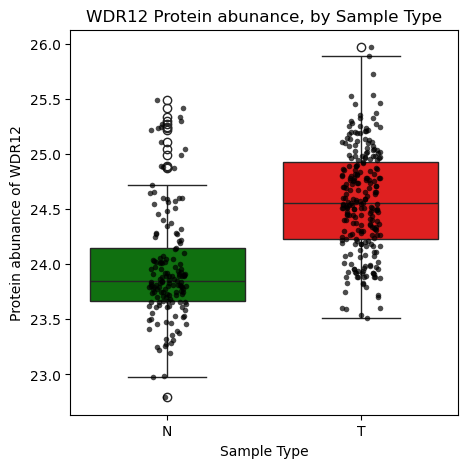

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_73141/1400845078.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


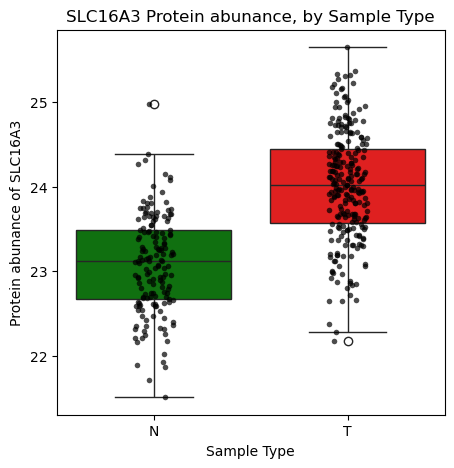

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_73141/1400845078.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


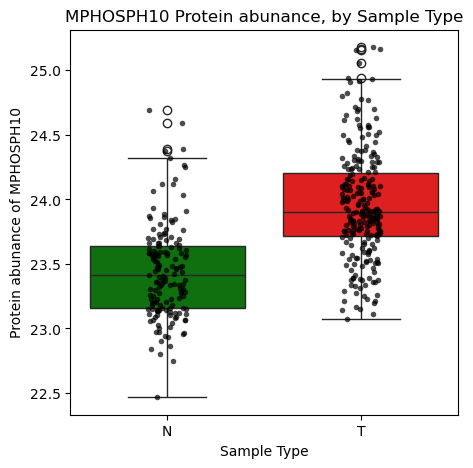

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_73141/1400845078.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


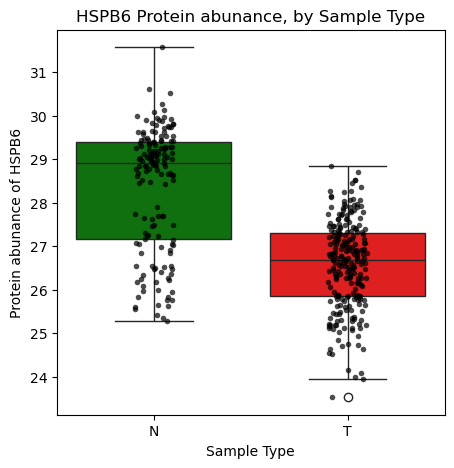

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_73141/1400845078.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


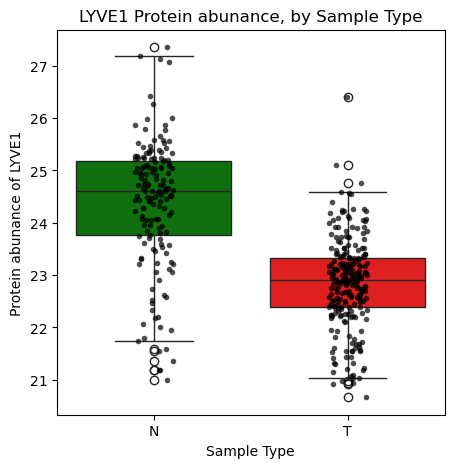

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_73141/1400845078.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


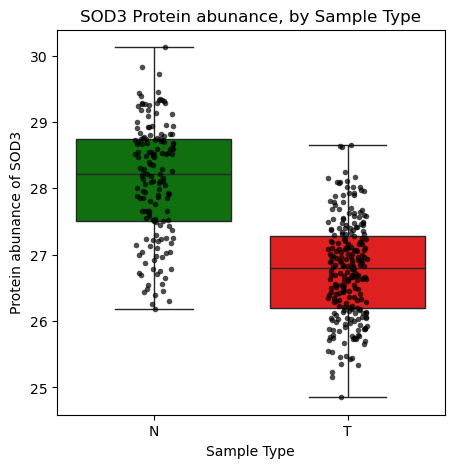

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_73141/1400845078.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


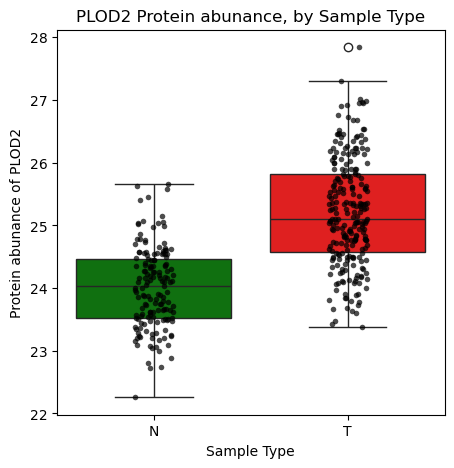

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_73141/1400845078.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


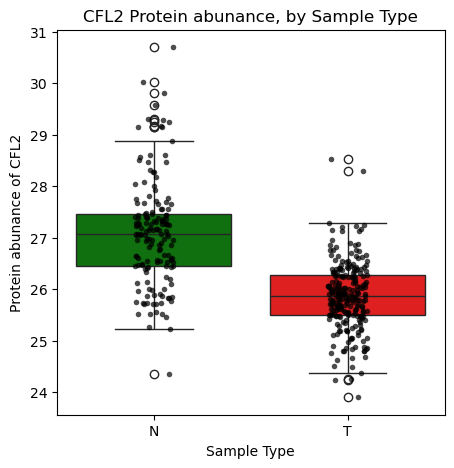

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_73141/1400845078.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


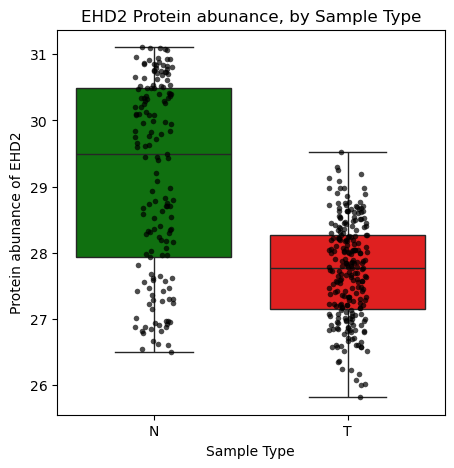

In [ ]:
### Boxplot on important genes in testing set
selected_genes = feature_importance_sort.iloc[0:10, ].index.to_list()

df = pd.DataFrame(
    adata_test.X, 
    index=adata_test.obs.index,
    columns=adata_test.var.index  # or adata.var['Gene'] if you prefer gene symbols
).join(adata_test.obs)


for gene in selected_genes:
    
    plt.figure(figsize=(5,5))
    sns.boxplot(
        data=df, 
        x="SampleType", 
        y=gene, 
        palette={"N": "green", "T": "red"}
    )
    sns.stripplot(
        data=df, 
        x="SampleType", 
        y=gene, 
        color="black", 
        size=4, 
        jitter=True, 
        alpha=0.7
    )
    plt.ylabel(f"Protein abunance of {adata.var.loc[gene, 'Gene']}")
    plt.xlabel("Sample Type")
    plt.title(f"{adata.var.loc[gene, 'Gene']} Protein abunance, by Sample Type")
    plt.show()


### SLC16A3 is cell surface protein    



In [15]:
# check if the NA is imputed
#adata[:, adata.var["Gene"] == "SCN7A" ].X

In [37]:

### Heatmap on top 200 important genes on testing set

selected_genes = feature_importance_sort.iloc[0:200, ].index.to_list()
adata_test_selected_genes = adata_test[:, selected_genes]

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(adata_test_selected_genes.X),
    columns=adata_test_selected_genes.var["Gene"],    # genes
    index=adata_test_selected_genes.obs.index   # samples
)
df_scaled_T = df_scaled.T
# Map disease status to colors
samples_type_col = "SampleType"
lut = {"T": "red", "N": "seagreen"}
samples_type_colors = adata_test_selected_genes.obs[samples_type_col].map(lut).to_dict()

# Map Cancer type to colors
cancer_type_col = "CancerType"
unique_cancers = adata_test_selected_genes.obs[cancer_type_col].unique()
import matplotlib
palette = matplotlib.cm.get_cmap("tab10", len(unique_cancers))
lut_cancer = {cancer: matplotlib.colors.rgb2hex(palette(i))
              for i, cancer in enumerate(unique_cancers)}
cancer_type_colors = adata_test_selected_genes.obs[cancer_type_col].map(lut_cancer).to_dict()


col_colors = pd.DataFrame({
    "SampleType": samples_type_colors,
    "CancerType": cancer_type_colors
}, index=adata_test_selected_genes.obs.index)


/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_73141/177053053.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = matplotlib.cm.get_cmap("tab10", len(unique_cancers))


/Users/Wendy/miniconda3/envs/multiomics/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/Wendy/miniconda3/envs/multiomics/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 900x900 with 0 Axes>

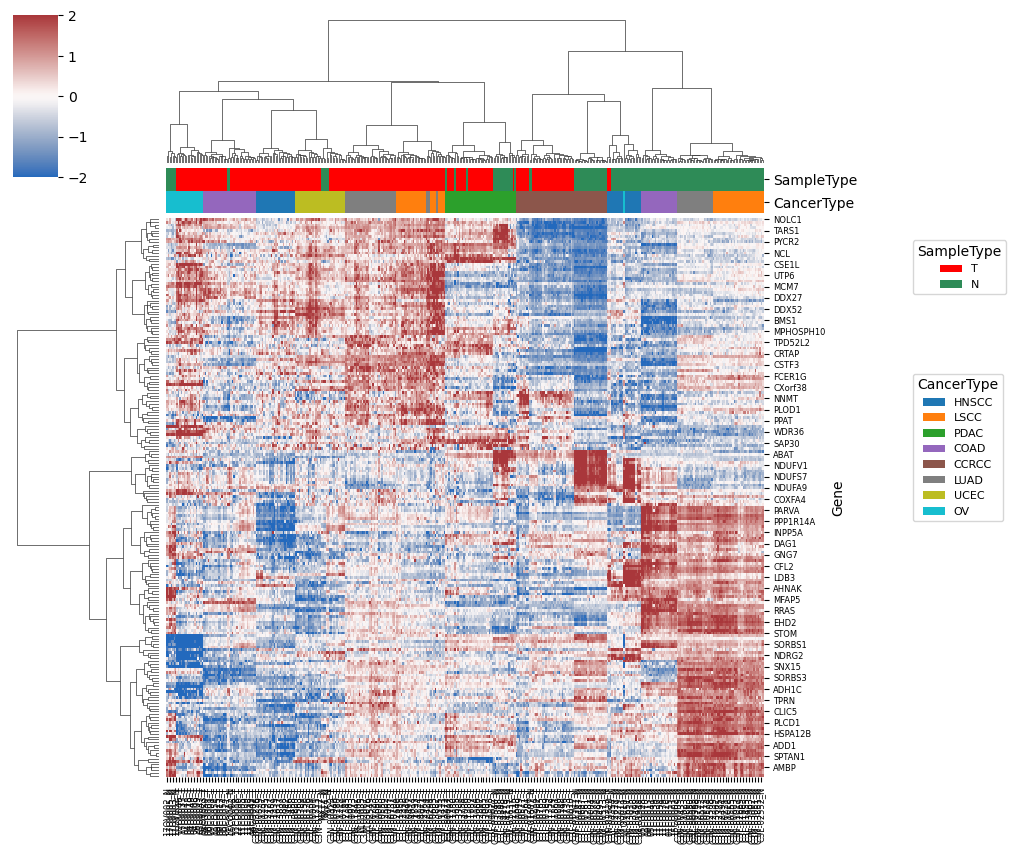

In [38]:
from matplotlib.patches import Patch

# Heatmap (keep your existing sns.clustermap code)
fig = plt.figure(figsize =(9,9))
g = sns.clustermap(
    df_scaled_T,
    col_colors=col_colors,
    cmap="vlag",
    method="ward",
    center=0,
    vmin=-2,
    vmax=2,
    xticklabels=True,
    yticklabels=True,
    figsize=(9,9)
)

# Skip labels for readability
yticks = g.ax_heatmap.get_yticks()
ylabels = [lab.get_text() for lab in g.ax_heatmap.get_yticklabels()]
g.ax_heatmap.set_yticks(yticks[::4])
g.ax_heatmap.set_yticklabels(ylabels[::4], fontsize=6, rotation=0)

xticks = g.ax_heatmap.get_xticks()
xlabels = [lab.get_text() for lab in g.ax_heatmap.get_xticklabels()]
g.ax_heatmap.set_xticks(xticks[::2])
g.ax_heatmap.set_xticklabels(xlabels[::2], fontsize=6, rotation=90)

# Create legend handles
handles_samples = [Patch(facecolor=lut[name], label=name) for name in lut]
handles_cancer = [Patch(facecolor=lut_cancer[name], label=name) for name in lut_cancer]

# Attach legends to the figure (not the axes) on the right
g.fig.legend(
    handles=handles_samples,
    title=samples_type_col,
    loc="center left",
    bbox_to_anchor=(1.02, 0.7),  # slightly to the right
    borderaxespad=0.,
    fontsize=8
)

g.fig.legend(
    handles=handles_cancer,
    title=cancer_type_col,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  # lower than the first
    borderaxespad=0.,
    fontsize=8
)

plt.show()


In [20]:
print(np.isfinite(df_scaled_T.values).all()) 

True


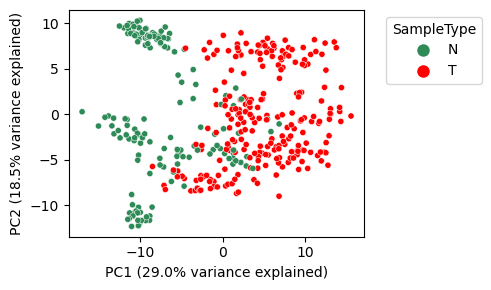

In [ ]:

### PCA on top 200 important genes on testing set

scaler = StandardScaler()
df_scaled = scaler.fit_transform(adata_test_selected_genes.X)
pca = PCA()
pca_result = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(
    data = pca_result[:, :2],
    columns= ['PC1', 'PC2'],
    index = adata_test_selected_genes.obs.index
).join(adata_test_selected_genes.obs)

var_explained = pca.explained_variance_ratio_ * 100

disease_status_col = "SampleType"
color_dict = {
    'T': 'red',      # Red
    'N': 'seagreen'   # Green
}
legend_order = ['N', 'T']

fig = plt.figure(figsize =(6,3))
sns.scatterplot(
    data = df_pca,
    x = 'PC1',
    y = 'PC2',
    hue = disease_status_col,
    s = 20,
    palette=color_dict
)

plt.xlabel(f'PC1 ({var_explained[0]:.1f}% variance explained)')
plt.ylabel(f'PC2 ({var_explained[1]:.1f}% variance explained)')

# Create handles and labels in the specific order
handles = []
labels = []
for category in legend_order:
    if category in color_dict:  # Make sure the category exists in your dictionary
        handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict[category], markersize=10))
        labels.append(category)

# Create the legend with the ordered handles and labels
plt.legend(handles, labels, title=disease_status_col, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.85, 1])  
plt.show()



/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_73141/4220163937.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = matplotlib.cm.get_cmap("tab10", len(unique_cancers))


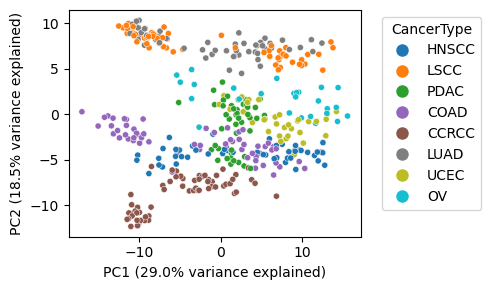

In [42]:

### PCA on top 200 important genes on testing set

scaler = StandardScaler()
df_scaled = scaler.fit_transform(adata_test_selected_genes.X)
pca = PCA()
pca_result = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(
    data = pca_result[:, :2],
    columns= ['PC1', 'PC2'],
    index = adata_test_selected_genes.obs.index
).join(adata_test_selected_genes.obs)

var_explained = pca.explained_variance_ratio_ * 100

# Map Cancer type to colors
cancer_type_col = "CancerType"
unique_cancers = adata_test_selected_genes.obs[cancer_type_col].unique()
import matplotlib
palette = matplotlib.cm.get_cmap("tab10", len(unique_cancers))
color_dict_cancer_type = {cancer: matplotlib.colors.rgb2hex(palette(i))
              for i, cancer in enumerate(unique_cancers)}

legend_order = color_dict_cancer_type.keys()

fig = plt.figure(figsize =(6,3))
sns.scatterplot(
    data = df_pca,
    x = 'PC1',
    y = 'PC2',
    hue = cancer_type_col,
    s = 20,
    palette=color_dict_cancer_type
)

plt.xlabel(f'PC1 ({var_explained[0]:.1f}% variance explained)')
plt.ylabel(f'PC2 ({var_explained[1]:.1f}% variance explained)')

# Create handles and labels in the specific order
handles = []
labels = []
color_dict = color_dict_cancer_type.copy()
for category in legend_order:
    if category in color_dict:  # Make sure the category exists in your dictionary
        handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict[category], markersize=10))
        labels.append(category)

# Create the legend with the ordered handles and labels
plt.legend(handles, labels, title=cancer_type_col, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.85, 1])  
plt.show()



/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_73141/1867634640.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] > 0]["Gene"].to_list()


          Gene_set                                 Term Overlap       P-value  \
0  KEGG_2021_Human    Ribosome biogenesis in eukaryotes   8/108  1.567784e-08   
1  KEGG_2021_Human                   Lysine degradation    3/63  2.287345e-03   
2  KEGG_2021_Human  Central carbon metabolism in cancer    3/70  3.088067e-03   
3  KEGG_2021_Human                 Base excision repair    2/33  8.265040e-03   
4  KEGG_2021_Human        Starch and sucrose metabolism    2/36  9.782805e-03   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.000001            0                     0   21.138133   
1          0.078231            0                     0   12.410625   
2          0.078231            0                     0   11.110075   
3          0.100238            0                     0   15.839108   
4          0.100238            0                     0   14.439361   

   Combined Score                                             Genes  
0      379.873765  UTP

<Axes: title={'center': 'UpRegulated 83 proteins from top 200 features'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

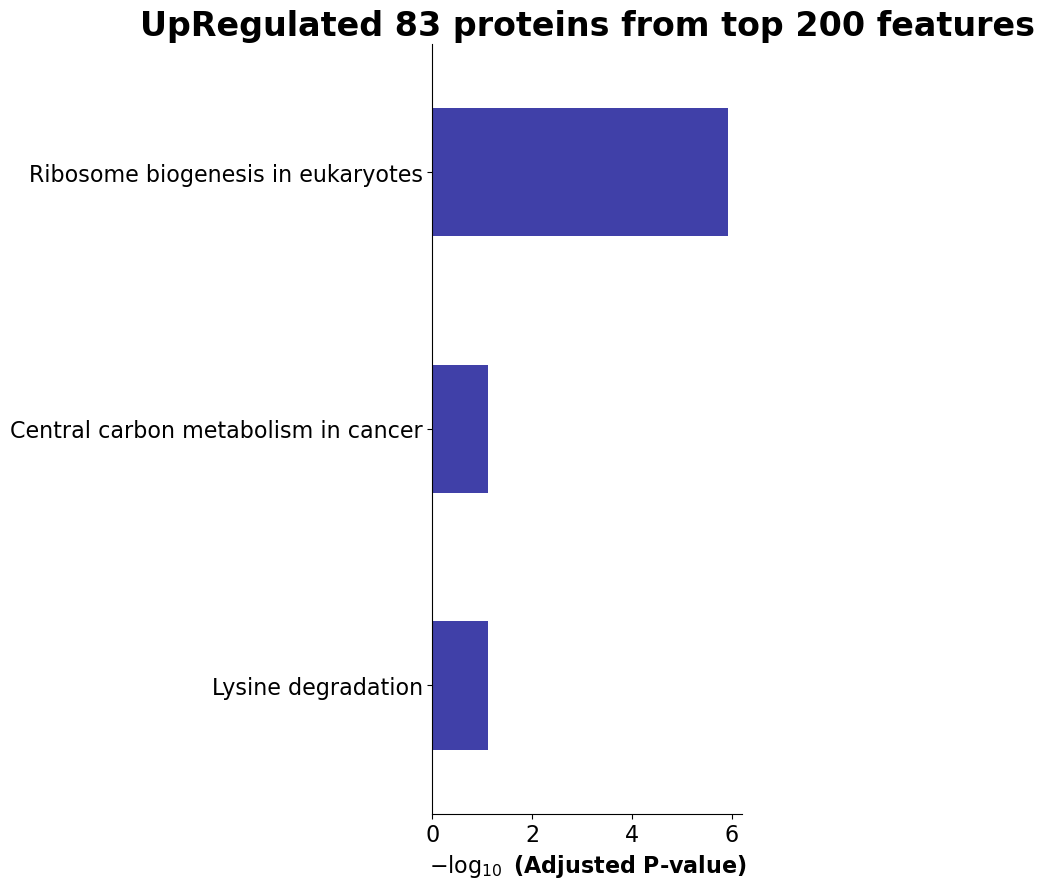

In [22]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] > 0]["Gene"].to_list()
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=glist, # or "./tests/data/gene_list.txt",
                 #gene_sets=['MSigDB_Hallmark_2020'],
                 gene_sets=['KEGG_2021_Human'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )
print(enr.results.head(5))
barplot(enr.results, cutoff=0.1, title=f'UpRegulated {len(glist)} proteins from top 200 features', figsize=(4, 10), color='darkblue')

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_73141/3919987112.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] < 0]["Gene"].to_list()


          Gene_set                                  Term Overlap  \
0  KEGG_2021_Human                        Focal adhesion  13/201   
1  KEGG_2021_Human               Diabetic cardiomyopathy  11/203   
2  KEGG_2021_Human             Oxidative phosphorylation   9/133   
3  KEGG_2021_Human  Retrograde endocannabinoid signaling   9/148   
4  KEGG_2021_Human     Non-alcoholic fatty liver disease   9/155   

        P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  \
0  1.790993e-10      2.740220e-08            0                     0   
1  3.048771e-08      2.332310e-06            0                     0   
2  8.719968e-08      4.447184e-06            0                     0   
3  2.182267e-07      8.347170e-06            0                     0   
4  3.233665e-07      9.895014e-06            0                     0   

   Odds Ratio  Combined Score  \
0   13.095080      293.893930   
1   10.642738      184.182606   
2   13.278898      215.849349   
3   11.836930      181.551

<Axes: title={'center': 'DownRegulated 117 proteins from top 200 features'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

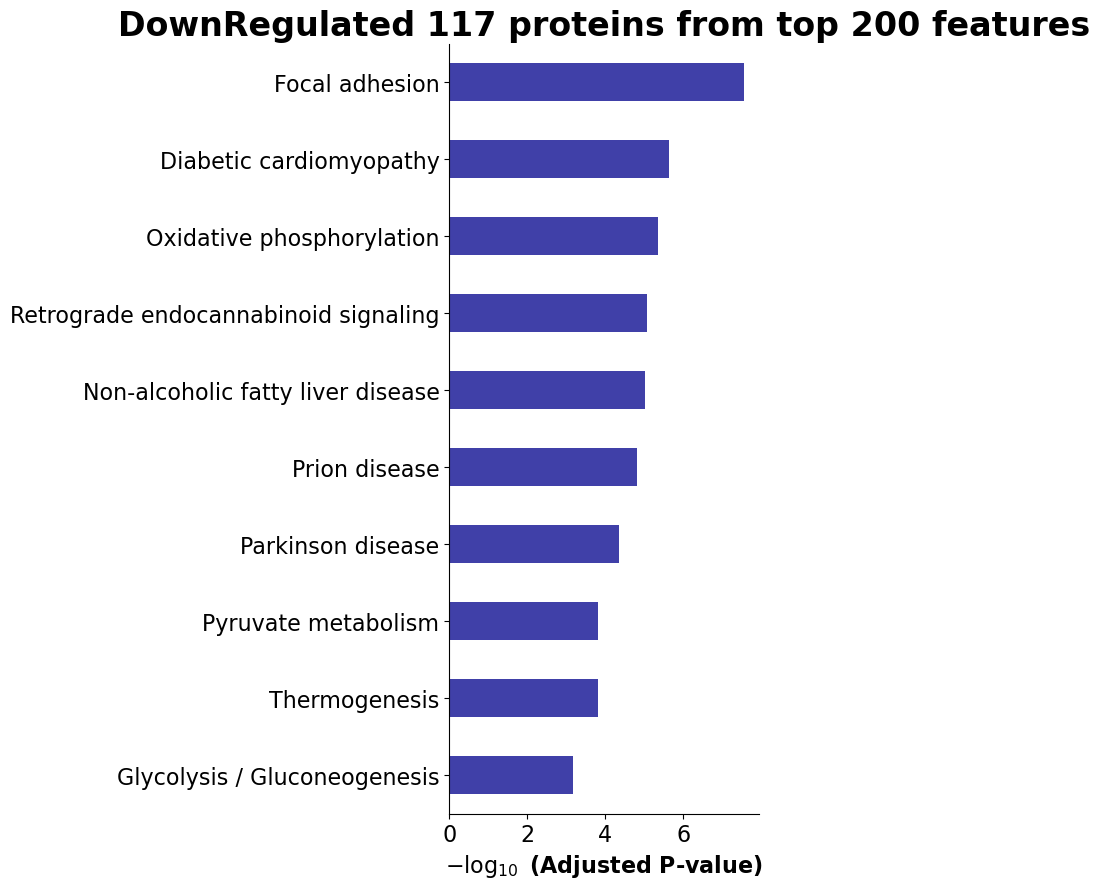

In [23]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] < 0]["Gene"].to_list()
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=glist, # or "./tests/data/gene_list.txt",
                 #gene_sets=['MSigDB_Hallmark_2020'],
                 gene_sets=['KEGG_2021_Human'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )
print(enr.results.head(5))
barplot(enr.results, cutoff=0.1, title=f'DownRegulated {len(glist)} proteins from top 200 features', figsize=(4, 10), color='darkblue')

          Gene_set                          Term Overlap       P-value  \
0  KEGG_2021_Human                Focal adhesion  13/201  1.234348e-07   
1  KEGG_2021_Human       Diabetic cardiomyopathy  12/203  9.960641e-07   
2  KEGG_2021_Human  Glycolysis / Gluconeogenesis    7/67  4.712502e-06   
3  KEGG_2021_Human           Pyruvate metabolism    6/47  7.079811e-06   
4  KEGG_2021_Human     Oxidative phosphorylation   9/133  7.807402e-06   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.000024            0                     0    7.252133   
1          0.000098            0                     0    6.553080   
2          0.000306            0                     0   11.932642   
3          0.000306            0                     0   14.904953   
4          0.000306            0                     0    7.476946   

   Combined Score                                              Genes  
0      115.363696  TNXB;CAV2;LAMB2;CAV1;ILK;PARVA;MYLK;RAP1A;CO

<Axes: title={'center': 'DisRegulated 200 proteins from top 200 features'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

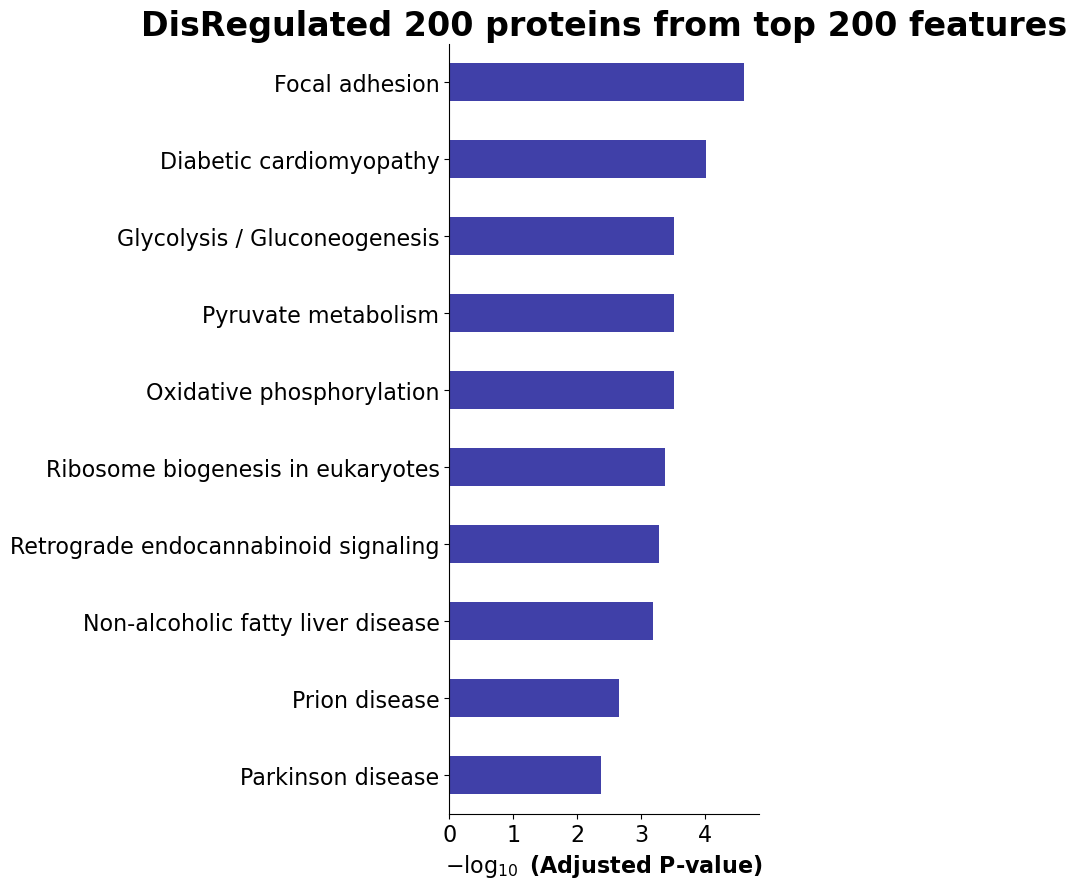

In [24]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
glist = feature_importance_sort.iloc[0:200, ]["Gene"].to_list()
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=glist, # or "./tests/data/gene_list.txt",
                 #gene_sets=['MSigDB_Hallmark_2020'],
                 gene_sets=['KEGG_2021_Human'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None # don't write to disk
                )
print(enr.results.head(5))
barplot(enr.results, cutoff=0.1, title=f'DisRegulated {len(glist)} proteins from top 200 features', figsize=(4, 10), color='darkblue')